In [236]:
from polair import _helpers as h
from polair import _calibration as calibration 
from polair import _corr_fcts as corr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
import subprocess
import glob
import os

# Manual processing steps

Not all steps of the turbulence processing can be automated. The definition segment times and the calibration has to be done manually. Here is the code which can be used for this. It uses the calibrated raw data of a flight. Restart kernel when changing flight.

## Find corrupted lines

If the preprocessing doesn't work, the downloaded files are sometimes corrupted. To find the corrupted lines and remove them from the files, here are some things you can try.

In [6]:
fn = "/Users/lakoeh001/AWI/Campaigns/20260103SANAT/Daten/RF10_20260129/20260129_RF10/20260129_P6_RF10_GPS1.ATEL.dat"

In [7]:
with open(fn, "rb") as f:
    for i, line in enumerate(f, start=1):
        try:
            line.decode("utf-8")
        except UnicodeDecodeError as e:
            print(f"Unicode error in line {i}: {e}")
            print(line[:200])  # show beginning of bad line
            break


In [14]:
3881 * 2 # If the file has an empty line between every timestep, we have to double the line number since the empty lines are not imported

7762

In [111]:
# Broken indices can lead to errors.

df = pd.read_csv(fn, header  = 4, sep = r'\s+', names = ["date", "time", f"var"])
#df = h.get_timestamps(df)

In [112]:
bad_idx = [i for i, x in enumerate(df["time"]) if len(str(x)) != 15]

In [113]:
bad_idx

[]

In [116]:
# Dublicated time stamps can also lead to errors

dup_times = df.loc[df["time"].duplicated(), "time"]
dup_times

713462    19:36:42.721124
713473    19:36:45.070794
Name: time, dtype: object

df = df[df[v].str.startswith("$GPGGA")].reset_index()

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
bad = gpgga[
    gpgga[v].str.len() < 60
]

bad

## Import the data

In [280]:
flight = 11
#config_file = "/Users/lakoeh001/AWI/Progr|ammierung/sanat_processing/config_sanat.yaml"
config_file = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml"

In [281]:
config = h.import_dictionary(config_file)
logfile = h.create_logfile(config)
vars = h.import_dictionary(config["paths"]["variables"])
out_vars = h.import_dictionary(config["paths"]["processed_variables"])
fhp_params = h.import_dictionary(config["paths"]["fiveholeprobe"])
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_nb = config["paths"]["outdirs"]["noseboom"]
flight_date = str(config["flights"][flight]["date"]).replace("-","")
campaign = config["campaign"]["name"]
fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"

data = xr.open_dataset(fn_in)

## Get start and stop

Determine start and stop time for time integration of INS and the data range provided in the final files.

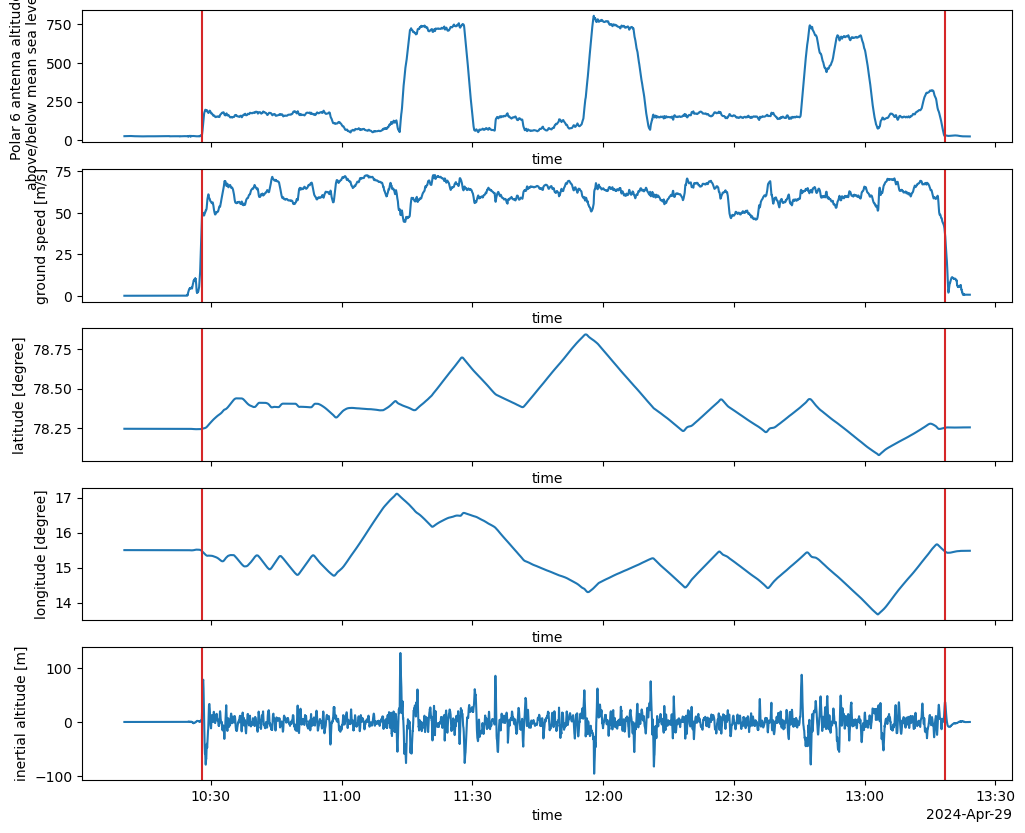

In [137]:
start = np.datetime64("2024-04-29T10:28:00")
stop = np.datetime64("2024-04-29T13:18:30")

# usefule variables: gs, h_ins, lat, lon, h_gpgga

#data.gs.plot()
fig, axs = plt.subplots(5,1,figsize=(12,10),sharex=True)

for v, ax in zip(["h_gpgga", "gs", "lat", "lon", "h"], fig.get_axes()):
    data[v].plot(ax = ax)
    ax.axvline(start, c = "tab:red")
    ax.axvline(stop, c = "tab:red")

## Get segments

Each flight is divided into segments to make it easier to work with the data.

In [142]:
# Calculate parameters useful for segment determination

start = config["flights"][flight]["start"]
stop = config["flights"][flight]["stop"]

pf = "noseboom"
twist_angle = np.deg2rad(config["campaign"]["noseboom_twist"])

for v in ["qb", "qc", "ps", "alpha", "beta"]:
    da = corr.alignement_correction(data, fhp_params, v, pf, twist_angle).rename(v)
    try:
        data_corr[v] = da
    except:
        data_corr = da.to_dataset()

# Some corrections:
data_corr["qc"] = data_corr["qc"].where(data_corr["qc"]>0, other = 0)
data_corr["alpha"] = data_corr["alpha"].where(data_corr["qc"]>500, other = 0)
data_corr["beta"] = data_corr["beta"].where(data_corr["qc"]>500, other = 0)

# adiabatic corrections for sensors in Rosemount/Goodrich housings
etaE = 1.00025  # recovery factor for deiced sensors
for temp in ["TejB", "ThuB", "Te_N", "ThuN", "TejN"]:
    name = f"{temp}_corr"
    if temp == "TejB":
        da = corr.sat_correction(data, data_corr, temp, recovery=etaE).rename(name)
    else:
        da = corr.sat_correction(data, data_corr, temp).rename(name)
    try:
        data_corr[name] = da
    except:
        data_corr = da.to_dataset()

# Correct relative humidity using the Magnus formula for the saturation pressure.
rh_corr = corr.humidity_correction(data.rFHuN, data.ThuN, data_corr.Te_N_corr)
data_corr["rFHuN_corr"] = rh_corr

# Correction of INS with GPS
w_ins = corr.get_w_ins(data, start, stop)
h_ins = corr.get_h_ins(w_ins["w_ins"])
data = xr.merge([data, w_ins, h_ins])

for v in ["lat", "lon", "gs", "h_ins", "w_ins", "vew", "vns"]:
    gps_corr = corr.correct_ins_with_gps(data, v)
    data_corr = xr.merge([data_corr, gps_corr])

ttrk_corr = corr.correct_ttrk_ins_with_gps(data, data_corr, "ttrk")
data_corr = xr.merge([data_corr, ttrk_corr])

# Calculate true airspeed
data_corr["tas"] = corr.get_true_air_speed(data_corr, pf)

for v in ["u", "v", "vertwind"]:
    wind_comp = corr.get_wind_component(data, data_corr, v, pf)
    data_corr[v] = wind_comp

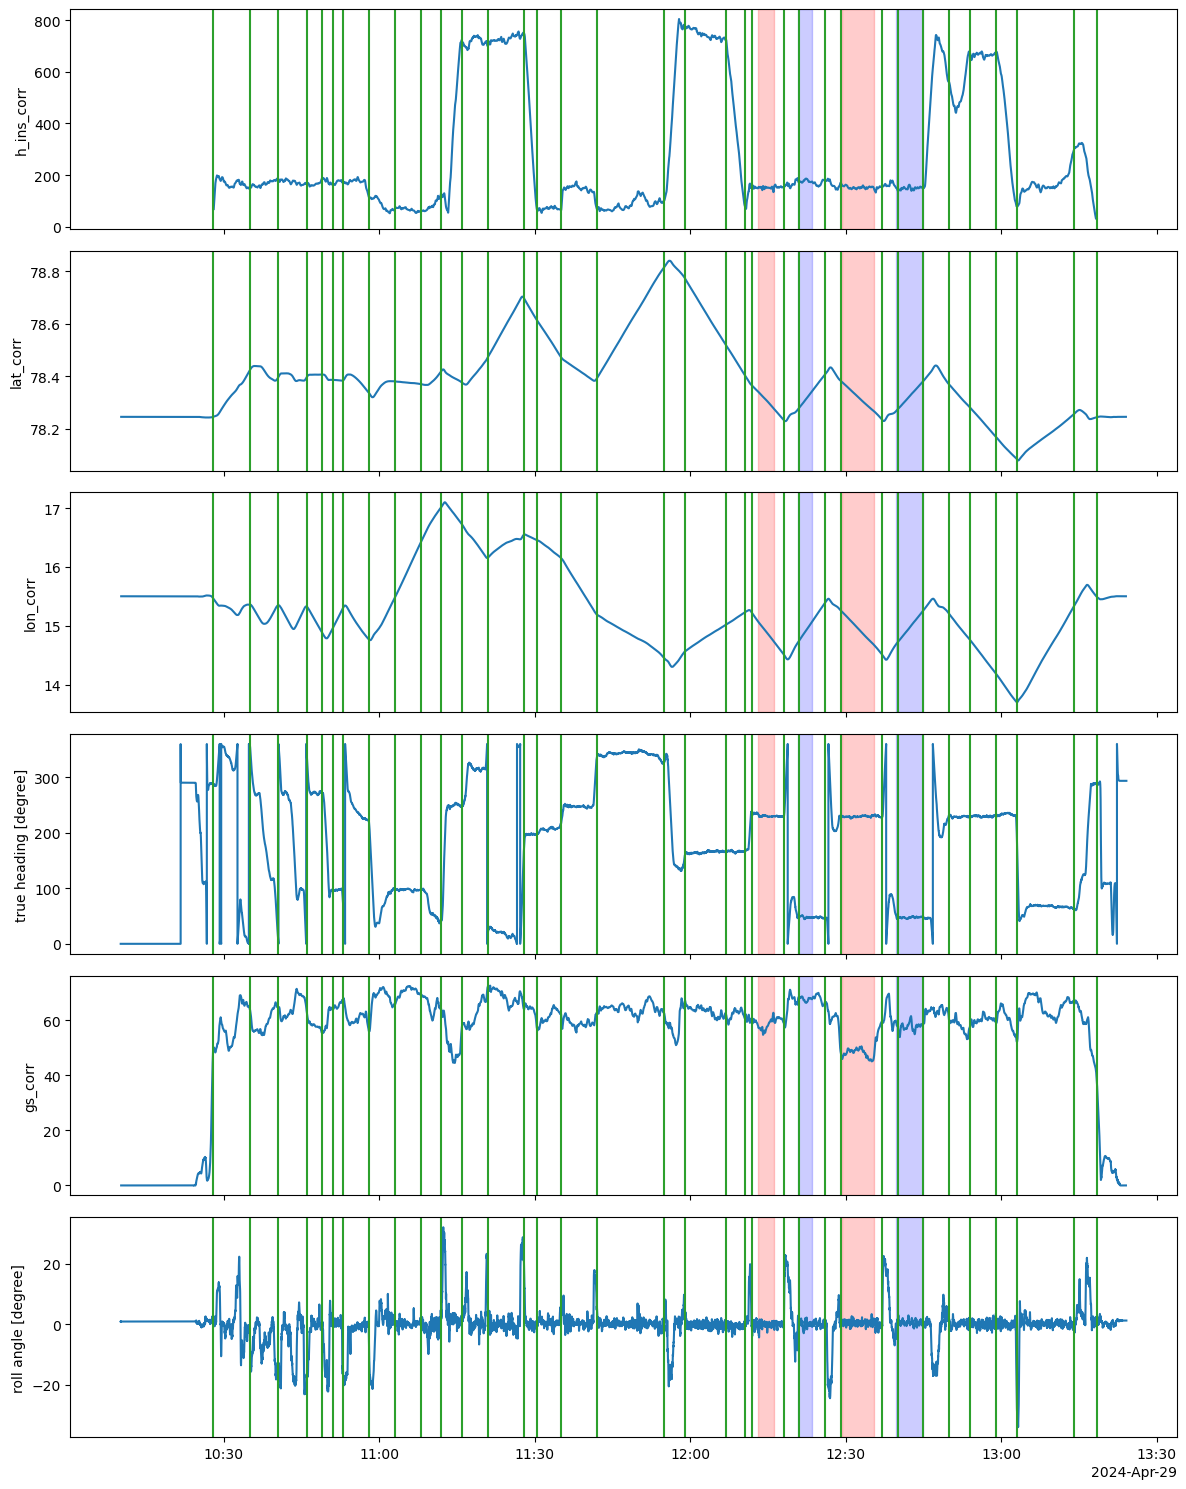

In [180]:
fig, axs = plt.subplots(6,1,figsize=(12,15),sharex=True)

data_corr.h_ins_corr.plot(ax = axs[0])
data_corr.lat_corr.plot(ax = axs[1])
data_corr.lon_corr.plot(ax = axs[2])
data.thdg.plot(ax = axs[3])
data_corr.gs_corr.plot(ax = axs[4])
data["roll"].plot(ax = axs[5])

seglist = []

calsegs = []

# If segments are aleady determined, it is possible to plot them here with the switch:
if 1:
    try:
        seg_fn = config["paths"]["segments"]
        segments = h.import_dictionary(seg_fn)
        flight_segments = segments["flights"][flight]["segments"]
        for i in np.arange(len(flight_segments)):
            t = flight_segments[i]['time']
            seglist.append(t)
    except:
        print("No segment file available")

seglist = np.array(seglist).astype("datetime64")
calsegs = np.array(calsegs).astype("datetime64")

for ax in fig.get_axes():
    ax.set_xlabel("")
    for s in seglist:
        ax.axvline(s, color = "tab:green")
    for cal in calsegs:
        ax.axvline(cal, color = "tab:red")

# If calibration segments are already available:
for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

plt.tight_layout()

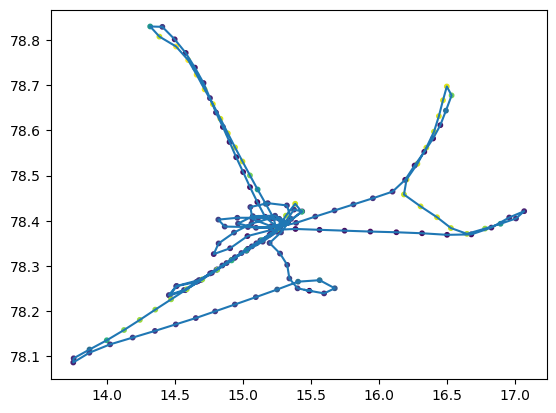

In [197]:
# The flight track might also be useful for the segemnts:

min = data_corr.resample(time = "1min").mean()

plt.plot(min.lon_corr, min.lat_corr)
plt.scatter(min.lon_corr, min.lat_corr, c=min.h_ins_corr.values, s=10, cmap="viridis")

#### Identification of calibration segments:

Calibration segments are mainly identified looking at the segmentation above. However, it might be helpful to look at the out and ret part and see if they fit together.

In [198]:
seg_a = slice("2024-04-29T12:13:10", "2024-04-29T12:16:12")
seg_b = slice("2024-04-29T12:20:50", "2024-04-29T12:23:27")

In [211]:
print(f"out: alt = {data_corr.sel(time = seg_a).h_ins_corr.mean().values:.3f}, tas = {data_corr.sel(time = seg_a).tas.mean().values:.3f}, thdg = {data.sel(time = seg_a).thdg.mean().values:.2f}, lat = {data_corr.sel(time = seg_a).lat_corr.values[0]:.3f}-{data_corr.sel(time = seg_a).lat_corr.values[-1]:.3f}, lon = {data_corr.sel(time = seg_a).lon_corr.values[0]:.3f}-{data_corr.sel(time = seg_a).lon_corr.values[-1]:.3f}")
print(f"ret: alt = {data_corr.sel(time = seg_b).h_ins_corr.mean().values:.3f}, tas = {data_corr.sel(time = seg_b).tas.mean().values:.3f}, thdg + 180 = {((data.sel(time = seg_b).thdg.mean().values + 180)%360):.2f}, lat = {data_corr.sel(time = seg_b).lat_corr.values[-1]:.3f}-{data_corr.sel(time = seg_b).lat_corr.values[0]:.3f}, lon = {data_corr.sel(time = seg_b).lon_corr.values[-1]:.3f}-{data_corr.sel(time = seg_b).lon_corr.values[0]:.3f}")

out: alt = 150.061, tas = 61.655, thdg = 229.88, lat = 78.341-78.275, lon = 15.063-14.723
ret: alt = 176.438, tas = 62.196, thdg + 180 = 228.05, lat = 78.342-78.276, lon = 15.062-14.722


### Segmentation documentation

For the GitHub Repos, I want to transform the segmentation list in an html table.

In [7]:
# This is for having a csv file with the times and the segment types and comments. There might be a more elegant way to do this, maybe adjust for the next campaign.

#fn_in = "/Users/lakoeh001/AWINextcloud/personal/lakoeh001/campaigns/2026sanat/flights/SANAT_FlightSegments.csv"
fn_in = "/Users/lakoeh001/AWINextcloud/personal/lakoeh001/campaigns/2024bacsam2/BACSAM2FlightSegmentTypes.csv"
df = pd.read_csv(fn_in, sep = ";")
byflight = df.groupby(by = "Flight")

In [8]:
flight_dict = {}
#flights = [11,12,21,22,31,32,33,4,5,6,7,8,9,10] # SANAT
flights = [1,2,3,40,41,42,5,6,7,8,9,10,11] # BACSAM II
for f in flights:
    selected_flight = byflight.get_group(f)
    flight_list = []
    for i in np.arange(len(selected_flight)):
        seg_info = selected_flight.iloc[i]
        if type(seg_info["Comment"]) == type("str"):
            comment = seg_info["Comment"]
        else:
            comment = ""
        segs = {"segment" : int(seg_info["Segment"]), "time": seg_info["Time"], "type": seg_info["Type"], "comment": comment}
        flight_list.append(segs)
    flight_dict[f] = {"segments": flight_list}

flight_segments = {"flights": flight_dict}

In [9]:
#fn_out = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.yaml" # SANAT
fn_out = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.yaml" # BACSAM II
with open(fn_out, 'w') as file:
    yaml.safe_dump(flight_segments, file, sort_keys=False)

In [10]:
def generate_html_table(data, output_file):
    html = []

    html.append('<table style="font-size:90%; border-collapse:collapse;">')

    html.append("""
<thead>
<tr>
<th>Flight</th>
<th>Segment</th>
<th>Time</th>
<th>Type</th>
<th>Comment</th>
</tr>
</thead>
<tbody>
""")

    for flight_id, flight_data in data["flights"].items():

        segments = flight_data["segments"]
        rowspan = len(segments)

        for i, seg in enumerate(segments):

            html.append("<tr>")

            # Only write flight number once with rowspan
            if i == 0:
                html.append(f'<td rowspan="{rowspan}">{flight_id}</td>')

            html.append(f"<td>{seg['segment']}</td>")
            html.append(f"<td>{seg['time']}</td>")
            html.append(f"<td>{seg['type']}</td>")
            html.append(f"<td>{seg.get('comment', '')}</td>")

            html.append("</tr>")

    html.append("</tbody></table>")

    with open(output_file, "w") as f:
        f.write("\n".join(html))

    print(f"HTML table written to {output_file}")

In [11]:
# SANAT
#fn_flightsegs = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.yaml"
#fn_html_out = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.html"

# BACSAM II
fn_flightsegs = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.yaml"
fn_html_out = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.html"

with open(fn_flightsegs) as f:
    segments = yaml.safe_load(f)

generate_html_table(segments, fn_html_out)

HTML table written to /Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.html


## Determine twist angle

The five-hole-probe was a bit tilted for some of the campaigns. The tilt is determined here and noted in the config file. Alpha and beta will then be corrected by the tilt angle.

I normalize the pressure with the dynamic pressure to correct for different speeds. This makes sense since the dynamic pressure scales quadratically with the tas.

In [243]:
mus = xr.DataArray(
    np.linspace(-10, 10, 21),
    dims="mu"
)
date_dict = {1: "20240407", 2: "20240410", 3: "20240411", 40: "20240413", 41: "20240413", 42: "20240413", 5: "20240415", 6: "20240417", 7: "20240423", 8: "20240424", 9: "20240425", 10: "20240426", 11: "20240429"}

result_sum = 0
for flight in [1, 2, 3, 40, 41, 42, 5, 6, 7, 8, 9, 10, 11]:
    date = date_dict[flight]
    fn = f"/Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/raw/BACSAM2_{date}_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn)
    start = np.datetime64(config["flights"][flight]["start"])
    stop = np.datetime64(config["flights"][flight]["stop"])
    sel = data.sel(time = slice(start + np.timedelta64(5,"m"),stop - np.timedelta64(5,"m")))
    result = (
        (np.cos(np.deg2rad(mus)) * data.qbN - np.sin(np.deg2rad(mus)) * sel.qaN) / sel.qcN
    ).mean(axis = 1)
    result_sum = result + result_sum

beta_mean = result_sum/13

In [244]:
beta_mean = xr.Dataset(coords = {"mu": mus}, data_vars = {"beta_mean": (["mu"], beta_mean.values)})

In [245]:
m,c  = np.polyfit(beta_mean.mu.values,beta_mean.beta_mean.values,1)

In [246]:
# The tilt angle is the root:
-c/m

-5.578364749844413

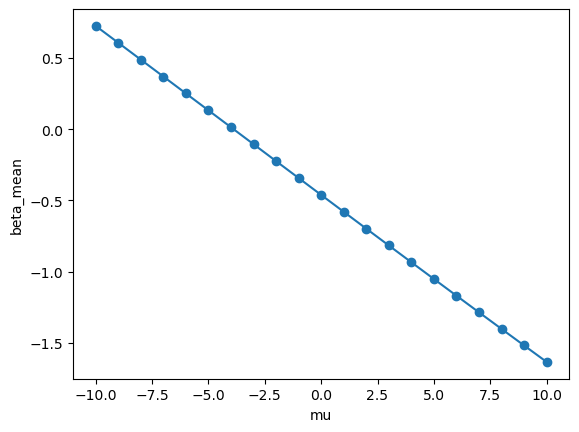

In [237]:
beta_mean.beta_mean.plot(marker = "o")

## Noseboom calibration

### dynamic pressure q

We do this according to the explanation in Hartmann 2018. One can either do the fit with or without offset.

In [282]:
def get_rho(ds, ds_proc):
    Rs = 287.0528
    rho = ds.psN / (Rs * ds_proc.t_air)
    return rho

In [283]:
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_nb = config["paths"]["outdirs"]["noseboom"]
campaign = config["campaign"]["name"]

In [284]:
qref = []
qi = np.array([])
gammaout = np.array([])
gammaret = np.array([])

for flight in list(config["flights"].keys()):
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    try:
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments)/2 + 1)
        for j in np.arange(1,num):
            out = data.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret = data.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))
            out_proc = data_proc.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret_proc = data_proc.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))

            out_proc["gs_corr"] = out_proc["gs"]
            ttrk_out = corr.correct_ttrk_ins_with_gps(out, out_proc,"ttrk")
            ret_proc["gs_corr"] = ret_proc["gs"]
            ttrk_ret = corr.correct_ttrk_ins_with_gps(ret, ret_proc,"ttrk")

            gamma_out = (np.deg2rad(out.thdg - ttrk_out.ttrk_corr)).mean()
            gammaout = np.append(gammaout, gamma_out.values)
            gamma_ret = (np.deg2rad(ret.thdg - ttrk_ret.ttrk_corr)).mean()
            gammaret = np.append(gammaret, gamma_ret.values)
            v_ref = 0.5 * (out_proc.gs.mean()/np.cos(gamma_out) + ret_proc.gs.mean()/np.cos(gamma_ret))
            rho = (get_rho(out, out_proc).mean() + get_rho(ret, ret_proc).mean())*0.5
            q_ref = 0.5 * rho * v_ref**2
            qref = np.append(qref, q_ref.values)
            q_i = (out.qcN.mean() + ret.qcN.mean())/2
            qi = np.append(qi, q_i.values)
    except:
        pass

In [127]:
# If fitted with offset use this:
m, b = np.polyfit(qi, qref, 1)

In [285]:
# If fitted without offset as linear function, use this:
m = np.sum(qi * qref) / np.sum(qi * qi)
b = 0

In [286]:
m

1.0544786463613591

In [287]:
b

0

In [288]:
fit = [b , b+ qi.max() * m ]

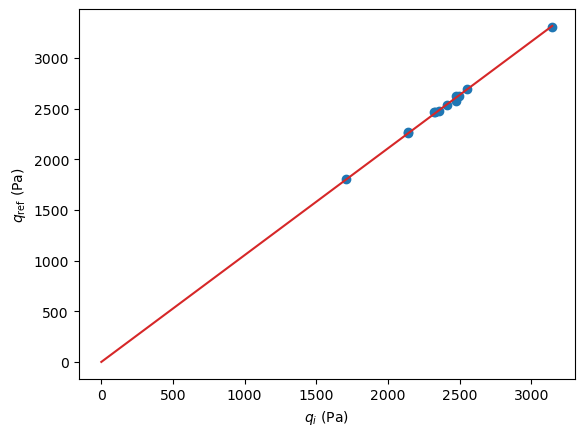

In [290]:
plt.scatter(qi, qref)
plt.plot([0, qi.max()], fit, c = "tab:red")
plt.xlabel(r"$q_i$ (Pa)")
plt.ylabel(r"$q_\text{ref}$ (Pa)")

#plt.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/q_fit.pdf")

Text(0, 0.5, '$\\gamma_\\text{ret}$ (˚)')

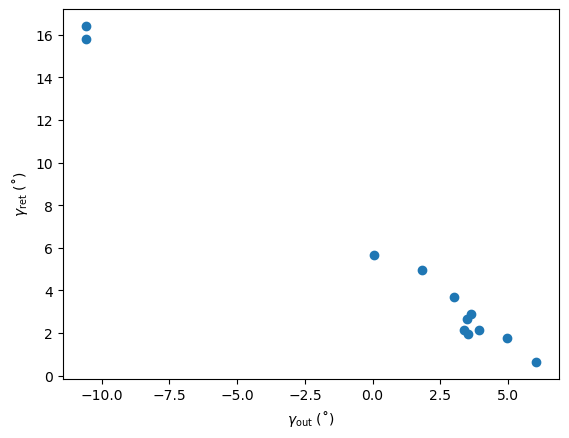

In [292]:
# This is a crosscheck if gamma_out and gamma_ret are consistent

plt.scatter(np.rad2deg(gammaout), np.rad2deg(gammaret))
#plt.plot([-12,6],[-12,6], c = "tab:red")
plt.xlabel(r"$\gamma_\text{out}$ (˚)")
plt.ylabel(r"$\gamma_\text{ret}$ (˚)")

### alpha

The alpha calibration is also explained in Hartmann et al 2028.

In [293]:
flights_with_calibration = [1, 8, 9, 10, 11] # BACSAM 2

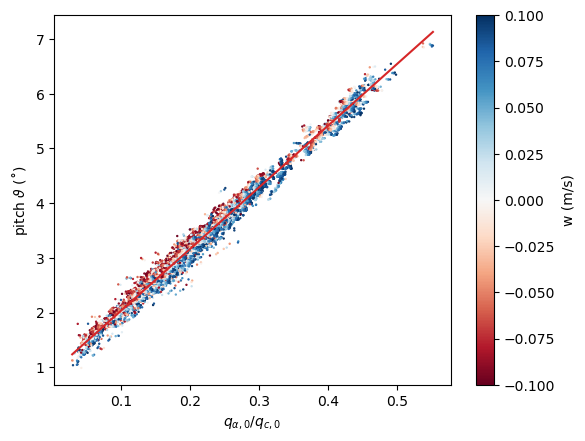

In [298]:
pitch_all = np.array([])
qratio_all = np.array([])
wcut = 0.1
waircraft_cut = 0.05
roll_max = 5

for flight in flights_with_calibration:
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    cal_segments = config["flights"][flight]["calibration"]
    num = int(len(cal_segments)/2 + 1)
    for j in np.arange(1,num):
        for dir in ["out", "ret"]:
            ds = data.sel(time = slice(np.datetime64(cal_segments[f"{dir}{j}"]["start"]),np.datetime64(cal_segments[f"{dir}{j}"]["stop"])))
            ds_proc = data_proc.sel(time = slice(cal_segments[f"{dir}{j}"]["start"],cal_segments[f"{dir}{j}"]["stop"]))
            sel = ds.where((np.abs(ds_proc.w) < wcut) & (np.abs(ds.w_bestvel) < waircraft_cut) & (np.abs(ds["roll"]) < roll_max), drop=True)
            sel_proc = ds_proc.where((np.abs(ds_proc.w) < wcut) & (np.abs(ds.w_bestvel) < waircraft_cut) & (np.abs(ds["roll"]) < roll_max), drop=True)
            pitch = sel.pit
            pitch_all = np.append(pitch_all, pitch.values)
            qratio = sel.qaN/sel.qcN
            qratio_all = np.append(qratio_all, qratio.values)
            plt.scatter(qratio,pitch, s = 0.5, c=sel_proc.w, vmin=-wcut, vmax=wcut, cmap="RdBu")

plt.xlabel(r"$q_{\alpha,0}/q_{c,0}$")
plt.ylabel(r"pitch $\vartheta$ (˚)")
plt.colorbar(label = "w (m/s)")
m, c = np.polyfit(qratio_all, pitch_all, 1)
fit = [qratio_all.min() * m + c, qratio_all.max() * m + c]
plt.plot([qratio_all.min(), qratio_all.max()], fit, c = "tab:red")

#plt.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/alpha_fit.pdf")

In [296]:
m

11.264472321068181

In [297]:
c

0.9123699248079745

### beta_0

In [299]:
pf = "noseboom"

In [300]:
calib_fn = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/fiveholeprobe_parameters_bacsam2.yaml"

def set_beta0(beta0):
    with open(calib_fn, "r") as f:
        calib = yaml.safe_load(f)
    calib[pf]["beta"]["a0"] = float(beta0)
    with open(calib_fn, "w") as f:
        yaml.dump(calib, f)

def delete_output_files():
    patterns = [
        outdir_nb + f"/{campaign}_*_noseboom_100Hz.nc",
    ]
    for pattern in patterns:
        for fn in glob.glob(pattern):
            os.remove(fn)
            print(f"Deleted: {fn}")

def run_polair():
    flights = "1 8 9 10 11"
    for flight in flights.split():
        subprocess.run(
            f"polair noseboom -f {flight} -c /Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml",
            shell=True, check=True
        )

def compute_score():
    uperp_cals = []
    upara_cals = []
    
    for flight in [1, 8, 9, 10, 11]:
        flight_date = str(config["flights"][flight]["date"]).replace("-", "")
        fn_in  = outdir_raw + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_calibrated_raw_data.nc"
        fn_out = outdir_nb + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_noseboom_100Hz.nc"
        
        data      = xr.open_dataset(fn_in)
        data_proc = xr.open_dataset(fn_out)
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments) / 2 + 1)
        
        for j in np.arange(1, num):
            uperp_sum = 0
            upara_sum = 0
            for dir in ["out", "ret"]:
                seg = cal_segments[f"{dir}{j}"]
                ds      = data.sel(time=slice(seg["start"], seg["stop"]))
                ds_proc = data_proc.sel(time=slice(seg["start"], seg["stop"]))
                thdg_rad = np.deg2rad(ds.thdg)
                uperp = ds_proc.u * np.cos(thdg_rad) - ds_proc.v * np.sin(thdg_rad)
                upara = ds_proc.u * np.sin(thdg_rad) + ds_proc.v * np.cos(thdg_rad)
                
                uperp_sum += uperp.mean().values
                upara_sum += upara.mean().values
            
            uperp_cals.append(uperp_sum)
            upara_cals.append(upara_sum)
    
    score_uperp = np.mean(np.abs(uperp_cals))
    score_upara = np.mean(np.abs(upara_cals))
    print(f"  mean|uperp| = {score_uperp:.4f},  mean|upara| = {score_upara:.4f}")
    return score_uperp, score_upara

In [304]:
# --- Main loop ---
beta0_values = np.linspace(-3.04,-2.96,9)
results = {}

for beta0 in beta0_values:
    print(f"\n--- beta0 = {beta0:.2f} ---")
    set_beta0(beta0)
    delete_output_files()
    run_polair()
    score_uperp, score_upara = compute_score()  # unpack tuple
    results[float(beta0)] = (score_uperp, score_upara)

best_beta0 = min(results, key=lambda b: results[b][0])
print(f"\nBest beta0: {best_beta0:.2f}  (uperp={results[best_beta0][0]:.4f}, upara={results[best_beta0][1]:.4f})")


--- beta0 = -3.04 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240424_RF08_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240407_RF01_noseboom_100Hz.nc
  mean|uperp| = 0.6861,  mean|upara| = 2.9691

--- beta0 = -3.03 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240426_RF10_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240425_RF09_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240424_RF08_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240407_RF01_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240429_RF11_noseboom_100Hz.nc
  mean|uperp| = 0.6832,  m

In [305]:
set_beta0(best_beta0)

In [121]:
results

{-3.15: (0.6862057937057422, 2.345757149879432),
 -3.1399999999999997: (0.6833988344714848, 2.3449027359138364),
 -3.13: (0.6805918400867269, 2.3440508867006153),
 -3.12: (0.6777848106369754, 2.3432016022657147),
 -3.11: (0.6749777462077363, 2.3423548826350067),
 -3.0999999999999996: (0.6721706468845192, 2.3415107278342826),
 -3.09: (0.6693635127528325, 2.340669137889259),
 -3.08: (0.6667331504801203, 2.3398301128255707),
 -3.07: (0.6677227699584188, 2.3389936526687753),
 -3.0599999999999996: (0.6726090905445735, 2.338159757444354),
 -3.05: (0.6775346882881902, 2.337328427177708)}

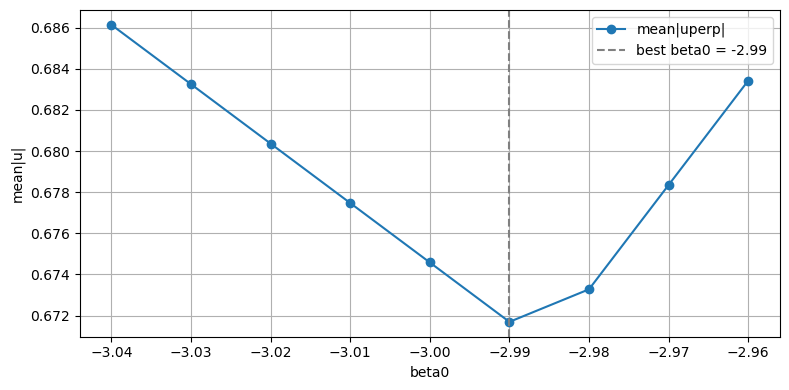

In [307]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
#ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#fig.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/beta0_determination.pdf")

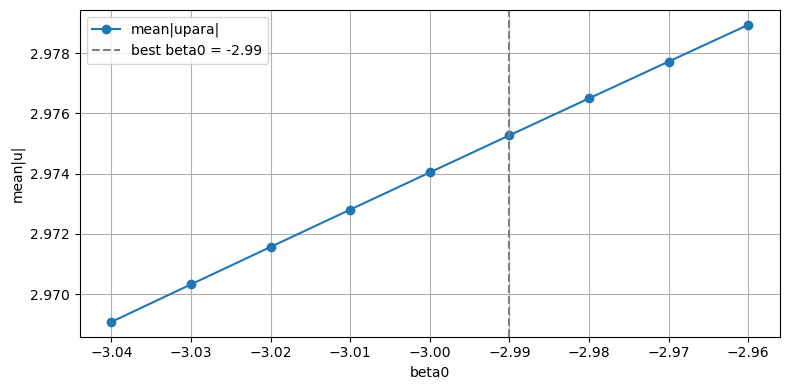

In [308]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
#ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## T-Bird calibration

### dynamic pressure T-Bird

I don't have to do the calibration for each campaign individually. So when SANAT is processed, I can combine these two campaigns and get more calibration segments.

In [50]:
flights_with_calibration = [9]
flights_with_tbird = [41, 5, 6, 7, 8, 9]

In [197]:
def get_rho(ds, ds_proc):
    Rs = 287.0528
    rho = ds.psT / (Rs * ds_proc.t_air)
    return rho

In [198]:
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_tb = config["paths"]["outdirs"]["tbird"]
campaign = config["campaign"]["name"]

In [263]:
qref = []
qi = np.array([])
gammaout = np.array([])
gammaret = np.array([])

for flight in flights_with_tbird:
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    fn_out = outdir_tb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_tbird_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    try:
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments)/2 + 1)
        for j in np.arange(1,num):
            out = data.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret = data.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))
            out_proc = data_proc.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret_proc = data_proc.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))
            
            gamma_out = (np.deg2rad(out.thdg_inat - out.ttrk_inat)).mean()
            gammaout = np.append(gammaout, gamma_out.values)
            gamma_ret = (np.deg2rad(ret.thdg_inat - ret.ttrk_inat)).mean()
            gammaret = np.append(gammaret, gamma_ret.values)
            v_ref = 0.5 * (out_proc.gs.mean()/np.cos(gamma_out) + ret_proc.gs.mean()/np.cos(gamma_ret))
            rho = (get_rho(out, out_proc).mean() + get_rho(ret, ret_proc).mean())*0.5
            q_ref = 0.5 * rho * v_ref**2
            qref = np.append(qref, q_ref.values)
            q_i = (out.qcT.mean() + ret.qcT.mean())/2
            qi = np.append(qi, q_i.values)
    except:
        pass

In [127]:
# If fitted with offset use this:
m, b = np.polyfit(qi, qref, 1)

In [264]:
# If fitted without offset as linear function, use this:
m = np.sum(qi * qref) / np.sum(qi * qi)
b = 0

In [265]:
m

1.1728856717776102

In [266]:
b

0

In [267]:
fit = [b , b+ qi.max() * m ]

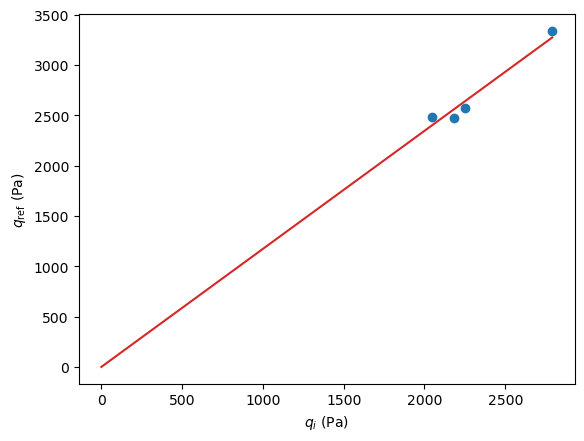

In [268]:
plt.scatter(qi, qref)
plt.plot([0, qi.max()], fit, c = "tab:red")
plt.xlabel(r"$q_i$ (Pa)")
plt.ylabel(r"$q_\text{ref}$ (Pa)")

#plt.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/q_fit_tbird.pdf")

### alpha T-Bird

In [258]:
flights_with_calibration = [9]

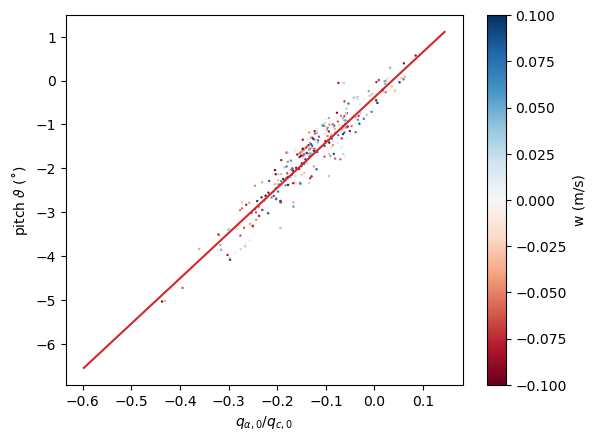

In [269]:
# Only calibration segments
pitch_all = np.array([])
qratio_all = np.array([])
wcut = 0.1
waircraft_cut = 0.05
roll_max = 5

for flight in flights_with_calibration:
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    ds = data
    fn_out = outdir_tb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_tbird_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    ds_proc = data_proc
    cal_segments = config["flights"][flight]["calibration"]
    num = int(len(cal_segments)/2 + 1)
    for j in np.arange(1,num):
        for dir in ["out", "ret"]:
            ds = data.sel(time = slice(np.datetime64(cal_segments[f"{dir}{j}"]["start"]),np.datetime64(cal_segments[f"{dir}{j}"]["stop"])))
            ds_proc = data_proc.sel(time = slice(cal_segments[f"{dir}{j}"]["start"],cal_segments[f"{dir}{j}"]["stop"]))
            sel = ds.where((np.abs(ds_proc.w) < wcut) & (np.abs(ds.w_bestvel) < waircraft_cut) & (np.abs(ds["roll"]) < roll_max), drop=True)
            sel_proc = ds_proc.where((np.abs(ds_proc.w) < wcut) & (np.abs(ds.w_bestvel) < waircraft_cut) & (np.abs(ds["roll"]) < roll_max), drop=True)
            pitch = -sel.pitch_inat
            pitch_all = np.append(pitch_all, pitch.values)
            qratio = sel.qaT/sel.qcT
            qratio_all = np.append(qratio_all, qratio.values)
    plt.scatter(qratio,pitch, s = 0.5, c=sel_proc.w, vmin=-wcut, vmax=wcut, cmap="RdBu")

plt.xlabel(r"$q_{\alpha,0}/q_{c,0}$")
plt.ylabel(r"pitch $\vartheta$ (˚)")
plt.colorbar(label = "w (m/s)")
m, c = np.polyfit(qratio_all, pitch_all, 1)
fit = [qratio_all.min() * m + c, qratio_all.max() * m + c]
plt.plot([qratio_all.min(), qratio_all.max()], fit, c = "tab:red")

#plt.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/alpha_fit_tbird.pdf")

In [260]:
m

10.32416063156572

In [261]:
c

-0.37886596011608353

### beta_0 T-Bird

In [270]:
pf = "tbird"

calib_fn = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/fiveholeprobe_parameters_bacsam2.yaml"

def set_beta0(beta0):
    with open(calib_fn, "r") as f:
        calib = yaml.safe_load(f)
    calib[pf]["beta"]["a0"] = float(beta0)
    with open(calib_fn, "w") as f:
        yaml.dump(calib, f)

def delete_output_files():
    patterns = [
        outdir_tb + f"/{campaign}_*_tbird_100Hz.nc",
    ]
    for pattern in patterns:
        for fn in glob.glob(pattern):
            os.remove(fn)
            print(f"Deleted: {fn}")

def run_polair():
    flights = "9"
    for flight in flights.split():
        subprocess.run(
            f"polair tbird -f {flight} -c /Users/lakoeh001/AWI/Programmierung/bacsam2_processing/config_bacsam2.yaml",
            shell=True, check=True
        )

def compute_score():
    uperp_cals = []
    upara_cals = []
    
    for flight in [9]:
        flight_date = str(config["flights"][flight]["date"]).replace("-", "")
        fn_in  = outdir_raw + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_calibrated_raw_data.nc"
        fn_out = outdir_tb + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_tbird_100Hz.nc"
        
        data      = xr.open_dataset(fn_in)
        data_proc = xr.open_dataset(fn_out)
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments) / 2 + 1)
        
        for j in np.arange(1, num):
            uperp_sum = 0
            upara_sum = 0
            for dir in ["out", "ret"]:
                seg = cal_segments[f"{dir}{j}"]
                ds      = data.sel(time=slice(seg["start"], seg["stop"]))
                ds_proc = data_proc.sel(time=slice(seg["start"], seg["stop"]))

                # Get corrected true track:
#                da = corr.reverse_antennas(ds, "ttrk_inat", True).rename("ttrk_inat_corr")
#                data_corr = da.to_dataset()
#                thdg = (ds.thdg_inat + 180)#corr.correct_ttrk_inat_with_gps(ds, data_corr)
                thdg_rad = np.deg2rad(ds.thdg_inat + 180)#ttrk_corr.ttrk_inat_corr)
                uperp = ds_proc.u * np.cos(thdg_rad) - ds_proc.v * np.sin(thdg_rad)
                upara = ds_proc.u * np.sin(thdg_rad) + ds_proc.v * np.cos(thdg_rad)
                
                uperp_sum += uperp.mean().values
                upara_sum += upara.mean().values
            
            uperp_cals.append(uperp_sum)
            upara_cals.append(upara_sum)
    
    score_uperp = np.mean(np.abs(uperp_cals))
    score_upara = np.mean(np.abs(upara_cals))
    print(f"  mean|uperp| = {score_uperp:.4f},  mean|upara| = {score_upara:.4f}")
    return score_uperp, score_upara

In [277]:
# --- Main loop ---
beta0_values = np.linspace(-1.4,-1.386,5)
results = {}

for beta0 in beta0_values:
    print(f"\n--- beta0 = {beta0:.3f} ---")
    set_beta0(beta0)
    delete_output_files()
    run_polair()
    score_uperp, score_upara = compute_score()  # unpack tuple
    results[float(beta0)] = (score_uperp, score_upara)

best_beta0 = min(results, key=lambda b: results[b][0])
print(f"\nBest beta0: {best_beta0:.3f}  (uperp={results[best_beta0][0]:.4f}, upara={results[best_beta0][1]:.4f})")


--- beta0 = -1.400 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
  mean|uperp| = 0.3578,  mean|upara| = 6.7730

--- beta0 = -1.396 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
  mean|uperp| = 0.3578,  mean|upara| = 6.7732

--- beta0 = -1.393 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
  mean|uperp| = 0.3577,  mean|upara| = 6.7733

--- beta0 = -1.389 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
  mean|uperp| = 0.3577,  mean|upara| = 6.7734

--- beta0 = -1.386 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
  mean|uperp| = 0.3606,  mean|upara| = 6.7736

Best beta0: -1.389  (uperp=0.3577, upara=6.7734)


In [278]:
set_beta0(best_beta0)

In [279]:
results

{-1.4: (0.3578184217825804, 6.773012338471149),
 -1.3964999999999999: (0.35776444575222044, 6.773157684066398),
 -1.3929999999999998: (0.3577104699068654, 6.773302553760748),
 -1.3895: (0.3576564942467044, 6.7734469475536585),
 -1.386: (0.3606277784022174, 6.773590865444591)}

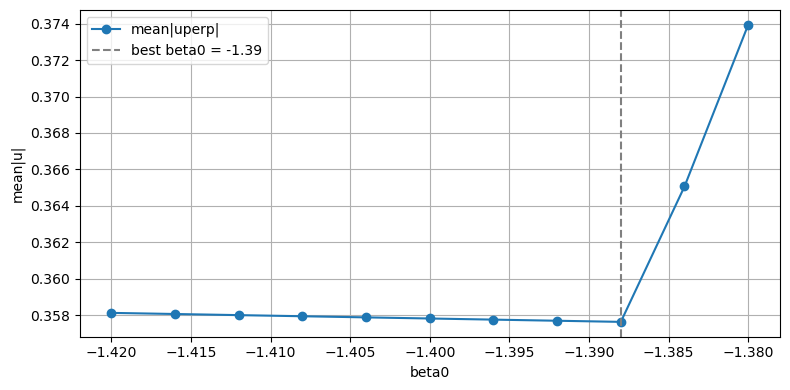

In [276]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
#ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#fig.savefig("/Users/lakoeh001/AWINextcloud/personal/lakoeh001/aircrafts/Formelsammlung/beta0_determination_tbird.pdf")

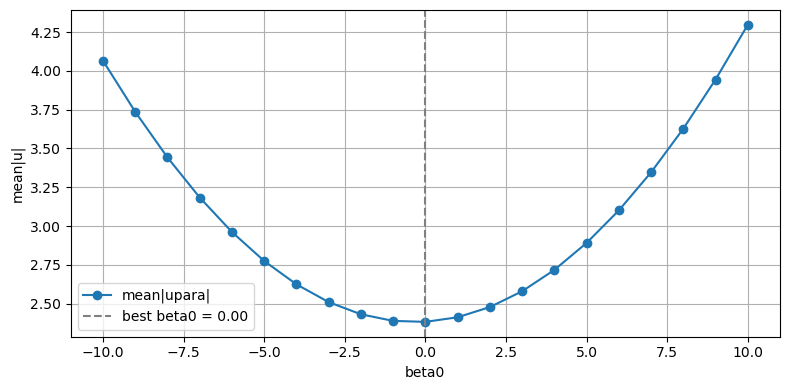

In [232]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
#ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()